In [1]:
import os
import zipfile

zip_filename = 'plantvillage.zip'
target_dir = './tomato_dataset'

# will Download only if zip doesn't exist
if not os.path.exists(zip_filename):
    print("Downloading dataset...")
    !kaggle datasets download -d mohitsingh1804/plantvillage
    print("Download complete!")
else:
    print(f"'{zip_filename}' already exists")

#Extract  only if it hasn't been extracted 
if not os.path.exists(target_dir):
    print("Extracting dataset...")
    os.makedirs(target_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print("Extracted")
else:
    print("already extracted")

'plantvillage.zip' already exists
already extracted


In [2]:
import torch
import torch.nn as nn
from torchvision.models import googlenet, GoogLeNet_Weights
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"./tomato_dataset/PlantVillage/train"

val_dir = f"./tomato_dataset/PlantVillage/val"

In [4]:
# Compute Mean and Std 

mean = torch.tensor([0.4496, 0.4651, 0.4003])
std = torch.tensor([0.1656, 0.1448, 0.1831])
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"{dataset_path}/train"
val_dir = f"{dataset_path}/val"


# Training Transform

train_transform = T.Compose([

    # Data Augmentation
    T.RandomResizedCrop(
        size=(224, 224),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),

    T.RandomHorizontalFlip(p=0.5),

    T.RandomRotation(degrees=15),

    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Convert to Tensor
    T.ToImage(),

    T.ToDtype(torch.float32, scale=True),

    # Normalize
    T.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])


# Validation Transform

val_transform = T.Compose([

    T.Resize((224, 224)),

    T.ToImage(),

    T.ToDtype(torch.float32, scale=True),

    T.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])


# Test-Time Augmentation 


tta_transforms = [

    T.Compose([
        T.Resize((224,224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomHorizontalFlip(p=1.0),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomRotation(10),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ])
]

In [5]:
# Dataset


train_data = ImageFolder(
    train_dir,
    transform=train_transform
)

val_data = ImageFolder(
    val_dir,
    transform=val_transform
)

In [6]:

# DataLoader


train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Classes:", train_data.classes)
print("Training Images:", len(train_data))
print("Validation Images:", len(val_data))

Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Training Images: 14529
Validation Images: 3631


In [7]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)

mps


In [8]:
class TomatoGoogLeNet(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        backbone = googlenet(
            weights=GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )

        backbone.fc = nn.Linear(
            backbone.fc.in_features,
            num_classes
        )

        self.model = backbone

    def forward(self, x):

        training = self.model.training

        self.model.eval()

        out = self.model(x)

        if training:
            self.model.train()

        return out

In [9]:
model = TomatoGoogLeNet(num_classes=10).to(device)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [10]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 11,990,138
Trainable Parameters : 11,990,138


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

epochs = 20

best_val_loss = float("inf")

patience = 5

counter = 0

In [12]:
from tqdm import tqdm
import torch

epochs = 20

best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):

    
    # Training
    
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader,
                               desc=f"Epoch {epoch+1}/{epochs}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    
    # Validation
   
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    
    # Scheduler
    
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

   
    # Save Best Model
   
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_googlenet.pth"
        )

        counter = 0

        print("Best model saved.")

    else:

        counter += 1

        print(f"Early Stopping Counter: {counter}/{patience}")

        if counter >= patience:

            print("Early stopping triggered.")

            break

print("Training Complete.")

Epoch 1/20:   0%|                                       | 0/455 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/20: 100%|█████████████████████████████| 455/455 [02:02<00:00,  3.72it/s]


Epoch [1/20] | LR: 0.001000 | Train Loss: 1.5334 | Train Acc: 45.86% | Val Loss: 1.3416 | Val Acc: 52.55%
Best model saved.


Epoch 2/20: 100%|█████████████████████████████| 455/455 [02:01<00:00,  3.74it/s]


Epoch [2/20] | LR: 0.001000 | Train Loss: 0.9103 | Train Acc: 67.73% | Val Loss: 0.5834 | Val Acc: 78.79%
Best model saved.


Epoch 3/20: 100%|█████████████████████████████| 455/455 [02:01<00:00,  3.73it/s]


...

Epoch [18/20] | LR: 0.000100 | Train Loss: 0.0369 | Train Acc: 98.76% | Val Loss: 0.0363 | Val Acc: 98.79%
Best model saved.


Epoch 19/20: 100%|████████████████████████████| 455/455 [02:22<00:00,  3.18it/s]


Epoch [19/20] | LR: 0.000100 | Train Loss: 0.0330 | Train Acc: 98.95% | Val Loss: 0.0325 | Val Acc: 99.04%
Best model saved.


Epoch 20/20: 100%|████████████████████████████| 455/455 [02:17<00:00,  3.32it/s]


Epoch [20/20] | LR: 0.000100 | Train Loss: 0.0338 | Train Acc: 98.80% | Val Loss: 0.0304 | Val Acc: 98.84%
Best model saved.
Training Complete.


In [19]:
from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = TomatoGoogLeNet(num_classes=10).to(device)

model.load_state_dict(

    torch.load(

        "best_googlenet.pth",

        map_location=device

    )

)

model.eval()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


TomatoGoogLeNet(
  (model): GoogLeNet(
    (conv1): BasicConv2d(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): BasicConv2d(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (conv3): BasicConv2d(
      (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (inception3a): Inception(
      (branch1): BasicConv2d(
        (conv): Conv2d(192, 64, kernel_size=(1, 1), str

In [20]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [21]:
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 98.84%
Precision: 0.9885
Recall   : 0.9884
F1 Score : 0.9884


In [16]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_data.classes,
    digits=4
)

print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9929    0.9906    0.9918       425
                        Tomato___Early_blight     0.9596    0.9500    0.9548       200
                         Tomato___Late_blight     0.9893    0.9712    0.9802       382
                           Tomato___Leaf_Mold     0.9947    0.9895    0.9921       191
                  Tomato___Septoria_leaf_spot     0.9831    0.9887    0.9859       354
Tomato___Spider_mites Two-spotted_spider_mite     0.9765    0.9940    0.9852       335
                         Tomato___Target_Spot     0.9856    0.9715    0.9785       281
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9953    0.9991    0.9972      1071
                 Tomato___Tomato_mosaic_virus     0.9610    1.0000    0.9801        74
                             Tomato___healthy     1.0000    1.0000    1.0000       318

                                     accu

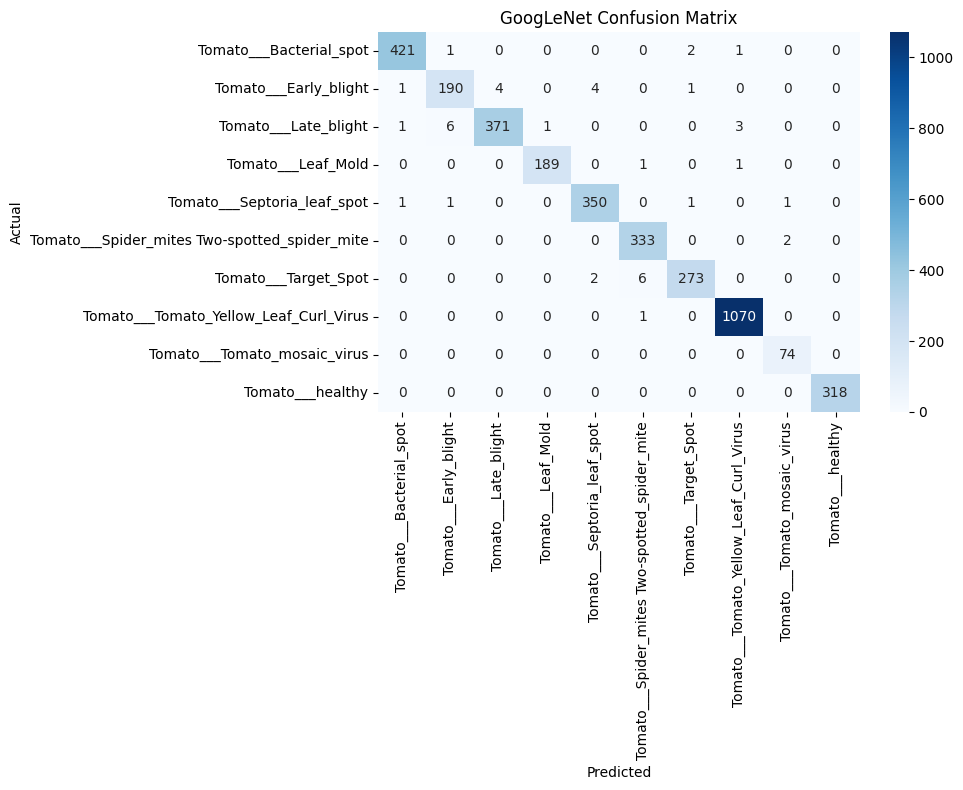

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GoogLeNet Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "googlenet_confusion_matrix.png",
    dpi=300
)

plt.show()

In [24]:
import pandas as pd
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

df = pd.DataFrame({

    "Class": train_data.classes,

    "Accuracy (%)": per_class_accuracy * 100

})

print(df)

df.to_csv(
    "per_class_accuracy.csv",
    index=False
)

                                           Class  Accuracy (%)
0                        Tomato___Bacterial_spot     99.058824
1                          Tomato___Early_blight     95.000000
2                           Tomato___Late_blight     97.120419
3                             Tomato___Leaf_Mold     98.952880
4                    Tomato___Septoria_leaf_spot     98.870056
5  Tomato___Spider_mites Two-spotted_spider_mite     99.402985
6                           Tomato___Target_Spot     97.153025
7         Tomato___Tomato_Yellow_Leaf_Curl_Virus     99.906629
8                   Tomato___Tomato_mosaic_virus    100.000000
9                               Tomato___healthy    100.000000


In [25]:


tta_transforms = [

    T.Compose([
        T.Resize((224,224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomHorizontalFlip(p=1.0),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomRotation(10),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ])
]

In [26]:
from PIL import Image
def tta_predict(image_path):

    image = Image.open(image_path).convert("RGB")

    probs = []

    for transform in tta_transforms:

        img = transform(image)

        img = img.unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(img)

            probs.append(
                torch.softmax(output, dim=1)
            )

    probs = torch.stack(probs)

    return probs.mean(0)
    

In [27]:
all_labels = []
all_predictions = []

samples = val_data.samples

for image_path, label in samples:

    prediction = tta_predict(image_path)

    pred = prediction.argmax(dim=1).item()

    all_predictions.append(pred)

    all_labels.append(label)
    

In [28]:
tta_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"TTA Accuracy : {tta_accuracy*100:.2f}%"
)

TTA Accuracy : 99.04%
